# Entrega sprint semana 6
## Experimentos A/B para deteccion de valores unitarios atipicos

**Objetivo:** comparar un baseline contra 2 variantes y adoptar la alternativa tecnicamente viable.  
**Metrica central:** F1-score para la clase outlier.  
**Metricas secundarias:** precision, recall, PR-AUC, registros detectados, tasa de deteccion y latencia.

In [1]:
# =============================================================================
# 1. CONFIGURACION GENERAL
# =============================================================================

import hashlib
import logging
import time
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, f1_score, precision_recall_curve, precision_score, recall_score
from sklearn.model_selection import GroupShuffleSplit, StratifiedShuffleSplit
from sqlalchemy import create_engine, text
from sqlalchemy.pool import NullPool

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

SERVIDOR = r"DESKTOP-OGU19A7\SQLEXPRESS,56878"
BASE_DATOS = "DB_GEE_DW_ADUANAS"
ESQUEMA = "SC_ADUANA"
PROCEDIMIENTO = "SP_VALORES_UNITARIOS"
DRIVER = "ODBC+Driver+17+for+SQL+Server"
FEC_INI = "2024-01-01"
FEC_FIN = "2024-12-31"

COL_GRUPO = "NUM_SPN_R"
COL_ADUANA = "ADUANA"
COL_FOB = "FOB_DOLAR"
COL_VU_ORIGEN = "MTO_VALOR_UNTARIO_V"
COL_FECHA_CANDIDATAS = ["FEC_NUM", "FECHA", "FEC_DECLARACION", "FECHA_DECLARACION"]

TEST_SIZE = 0.30
UMBRAL_Z_ROBUSTO_GT = 3.5
MIN_REGISTROS_GRUPO = 20

OUTPUT_DIR = Path("outputs_semana6")
LOGS_DIR = OUTPUT_DIR / "logs"
FIG_DIR = OUTPUT_DIR / "figuras"
DATA_DIR = OUTPUT_DIR / "datos"
for carpeta in [OUTPUT_DIR, LOGS_DIR, FIG_DIR, DATA_DIR]:
    carpeta.mkdir(parents=True, exist_ok=True)

LOG_CSV = LOGS_DIR / "metrics_experimentos_semana6.csv"
README_PATH = OUTPUT_DIR / "README_REPRODUCIBILIDAD.txt"
SNAPSHOT_PATH = DATA_DIR / "snapshot_semana6.csv"

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s", datefmt="%Y-%m-%d %H:%M:%S")
log = logging.getLogger("semana6")

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

print("CONFIGURACION LISTA")
print(f"Periodo: {FEC_INI} a {FEC_FIN}")
print(f"Seed: {SEED}")
print(f"Salida: {OUTPUT_DIR.resolve()}")

CONFIGURACION LISTA
Periodo: 2024-01-01 a 2024-12-31
Seed: 42
Salida: C:\Users\hp\Downloads\ROBOTICA\TESIS_2\notebooks\03_sprint2_complemento\outputs_semana6


In [3]:
# =============================================================================
# 2. FUNCIONES BASE
# =============================================================================

def crear_motor_sql_server() -> object:
    """
    Crea el motor de conexion hacia SQL Server usando autenticacion integrada.

    Returns
    -------
    object
        Motor SQLAlchemy configurado con NullPool.
    """
    url = f"mssql+pyodbc://{SERVIDOR}/{BASE_DATOS}?driver={DRIVER}&Trusted_Connection=yes"
    return create_engine(url, echo=False, poolclass=NullPool)


def cargar_datos_sql_server() -> pd.DataFrame:
    """
    Ejecuta el procedimiento almacenado y devuelve el dataset base.

    Returns
    -------
    pd.DataFrame
        Datos extraidos desde SQL Server.
    """
    motor = crear_motor_sql_server()
    sentencia = text(
        f"EXEC [{BASE_DATOS}].[{ESQUEMA}].[{PROCEDIMIENTO}] "
        f"@ACCION='EDA_BASE', @FEC_INI='{FEC_INI}', @FEC_FIN='{FEC_FIN}'"
    )
    with motor.connect() as conn:
        resultado = conn.execute(sentencia)
        df = pd.DataFrame.from_records(resultado.fetchall(), columns=list(resultado.keys()))
    if df.empty:
        raise RuntimeError("El procedimiento retorno 0 filas.")
    return df


def preparar_dataset(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Limpia columnas numericas, elimina registros no validos y crea variables base.

    Parameters
    ----------
    df_raw : pd.DataFrame
        Dataset original extraido desde SQL Server.

    Returns
    -------
    pd.DataFrame
        Dataset listo para experimentos A/B.
    """
    columnas_requeridas = [COL_GRUPO, COL_ADUANA, COL_FOB, COL_VU_ORIGEN]
    faltantes = [col for col in columnas_requeridas if col not in df_raw.columns]
    if faltantes:
        raise ValueError(f"Columnas faltantes: {faltantes}")

    columnas_base = columnas_requeridas.copy()
    for col_fecha in COL_FECHA_CANDIDATAS:
        if col_fecha in df_raw.columns:
            columnas_base.append(col_fecha)
            break

    df = df_raw[columnas_base].copy()
    df[COL_GRUPO] = df[COL_GRUPO].astype(str).str.strip()
    df[COL_ADUANA] = df[COL_ADUANA].astype(str).str.strip().str.upper()
    df["VU"] = pd.to_numeric(df[COL_VU_ORIGEN], errors="coerce")
    df[COL_FOB] = pd.to_numeric(df[COL_FOB], errors="coerce")
    df = df.dropna(subset=[COL_GRUPO, COL_ADUANA, COL_FOB, "VU"])
    df = df[(df[COL_FOB] > 0) & (df["VU"] > 0)].copy()

    conteo_grupo = df[COL_GRUPO].value_counts()
    grupos_validos = conteo_grupo[conteo_grupo >= MIN_REGISTROS_GRUPO].index
    df = df[df[COL_GRUPO].isin(grupos_validos)].copy()
    if df.empty:
        raise ValueError("El dataset quedo vacio despues de la limpieza.")

    df["LOG_VU"] = np.log1p(df["VU"])
    df["LOG_FOB"] = np.log1p(df[COL_FOB])
    return df.reset_index(drop=True)


def crear_etiqueta_proxy(df: pd.DataFrame) -> pd.DataFrame:
    """
    Crea una etiqueta proxy de outlier con z-score robusto por subpartida.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset limpio.

    Returns
    -------
    pd.DataFrame
        Dataset con columna y_true.
    """
    salida = df.copy()
    mediana = salida.groupby(COL_GRUPO)["LOG_VU"].transform("median")
    mad = salida.groupby(COL_GRUPO)["LOG_VU"].transform(lambda s: np.median(np.abs(s - np.median(s))))
    salida["Z_ROBUSTO"] = 0.6745 * (salida["LOG_VU"] - mediana) / (mad + 1e-9)
    salida["y_true"] = (salida["Z_ROBUSTO"].abs() >= UMBRAL_Z_ROBUSTO_GT).astype(int)
    return salida


def calcular_hash_archivo(ruta: Path) -> str:
    """
    Calcula el hash SHA256 de un archivo.

    Parameters
    ----------
    ruta : Path
        Ruta del archivo.

    Returns
    -------
    str
        Hash SHA256 en hexadecimal.
    """
    sha = hashlib.sha256()
    with ruta.open("rb") as archivo:
        for bloque in iter(lambda: archivo.read(1024 * 1024), b""):
            sha.update(bloque)
    return sha.hexdigest()

In [4]:
# =============================================================================
# 3. CARGA Y RESUMEN DEL DATASET
# =============================================================================

df_raw = cargar_datos_sql_server()
df_eval = preparar_dataset(df_raw)
df_eval = crear_etiqueta_proxy(df_eval)

SNAPSHOT_COLS = [COL_GRUPO, COL_ADUANA, COL_FOB, "VU", "LOG_VU", "LOG_FOB", "Z_ROBUSTO", "y_true"]
df_eval[SNAPSHOT_COLS].to_csv(SNAPSHOT_PATH, index=False, sep="|", encoding="utf-8")
HASH_SNAPSHOT = calcular_hash_archivo(SNAPSHOT_PATH)

resumen_dataset = pd.DataFrame({
    "indicador": ["registros_limpios", "subpartidas", "aduanas", "outliers_proxy", "tasa_outlier_proxy", "hash_snapshot_sha256"],
    "valor": [
        f"{len(df_eval):,}",
        f"{df_eval[COL_GRUPO].nunique():,}",
        f"{df_eval[COL_ADUANA].nunique():,}",
        f"{int(df_eval['y_true'].sum()):,}",
        f"{df_eval['y_true'].mean():.4f}",
        HASH_SNAPSHOT,
    ],
})

resumen_dataset

,indicador,valor
0,registros_limpios,"388,440"
1,subpartidas,444
2,aduanas,16
3,outliers_proxy,"20,016"
4,tasa_outlier_proxy,0.0515
5,hash_snapshot_sha256,bd70c05d1c0f5e10f3628e56fa6f31bf6042f3b7f77496...


In [5]:
# =============================================================================
# 4. SPLIT DE VALIDACION
# =============================================================================

def crear_split_validacion(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, str]:
    """
    Genera train y test priorizando split temporal, luego grupal y finalmente estratificado.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset con y_true.

    Returns
    -------
    tuple[pd.DataFrame, pd.DataFrame, str]
        Train, test y descripcion del split aplicado.
    """
    for col_fecha in COL_FECHA_CANDIDATAS:
        if col_fecha in df.columns:
            fechas = pd.to_datetime(df[col_fecha], errors="coerce")
            if fechas.notna().sum() > 0:
                temporal = df.assign(_fecha_split=fechas).dropna(subset=["_fecha_split"])
                corte = temporal["_fecha_split"].quantile(1 - TEST_SIZE)
                train = temporal[temporal["_fecha_split"] <= corte].drop(columns=["_fecha_split"])
                test = temporal[temporal["_fecha_split"] > corte].drop(columns=["_fecha_split"])
                if len(train) > 0 and len(test) > 0 and test["y_true"].nunique() > 1:
                    return train.copy(), test.copy(), f"Temporal por {col_fecha} con corte {corte.date()}"

    if df[COL_ADUANA].nunique() >= 2:
        splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
        train_idx, test_idx = next(splitter.split(df, y=df["y_true"], groups=df[COL_ADUANA]))
        train = df.iloc[train_idx].copy()
        test = df.iloc[test_idx].copy()
        if test["y_true"].nunique() > 1:
            return train, test, f"Grupal por {COL_ADUANA}"

    splitter = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
    train_idx, test_idx = next(splitter.split(df, df["y_true"]))
    return df.iloc[train_idx].copy(), df.iloc[test_idx].copy(), "Estratificado por y_true"

train_df, test_df, TIPO_SPLIT = crear_split_validacion(df_eval)

print("VALIDACION")
print("=" * 80)
print(f"Split aplicado : {TIPO_SPLIT}")
print(f"Train          : {len(train_df):,} filas | outlier_rate={train_df['y_true'].mean():.4f}")
print(f"Test           : {len(test_df):,} filas | outlier_rate={test_df['y_true'].mean():.4f}")
print(f"Seed           : {SEED}")

VALIDACION
Split aplicado : Grupal por ADUANA
Train          : 254,864 filas | outlier_rate=0.0384
Test           : 133,576 filas | outlier_rate=0.0767
Seed           : 42


In [7]:
# =============================================================================
# 5. EXPERIMENTOS A/B
# =============================================================================

def ajustar_iqr_por_grupo(train: pd.DataFrame, valor_col: str) -> tuple[pd.DataFrame, tuple[float, float]]:
    """
    Ajusta limites IQR por grupo usando solo train.

    Parameters
    ----------
    train : pd.DataFrame
        Datos de entrenamiento.
    valor_col : str
        Columna numerica usada para calcular IQR.

    Returns
    -------
    tuple[pd.DataFrame, tuple[float, float]]
        Tabla de limites por grupo y limites globales de respaldo.
    """
    limites = train.groupby(COL_GRUPO)[valor_col].quantile([0.25, 0.75]).unstack()
    limites.columns = ["q1", "q3"]
    limites["iqr"] = limites["q3"] - limites["q1"]
    limites["lim_inf"] = limites["q1"] - 1.5 * limites["iqr"]
    limites["lim_sup"] = limites["q3"] + 1.5 * limites["iqr"]
    limites = limites.reset_index()[[COL_GRUPO, "lim_inf", "lim_sup"]]
    q1_global = train[valor_col].quantile(0.25)
    q3_global = train[valor_col].quantile(0.75)
    iqr_global = q3_global - q1_global
    return limites, (q1_global - 1.5 * iqr_global, q3_global + 1.5 * iqr_global)


def predecir_iqr(test: pd.DataFrame, valor_col: str, limites: pd.DataFrame, globales: tuple[float, float]) -> np.ndarray:
    """
    Predice outliers aplicando limites IQR ajustados en train.

    Parameters
    ----------
    test : pd.DataFrame
        Datos de evaluacion.
    valor_col : str
        Columna numerica evaluada.
    limites : pd.DataFrame
        Limites IQR por grupo.
    globales : tuple[float, float]
        Limite inferior y superior global para grupos no vistos.

    Returns
    -------
    np.ndarray
        Vector binario de prediccion.
    """
    eval_df = test[[COL_GRUPO, valor_col]].merge(limites, on=COL_GRUPO, how="left")
    eval_df["lim_inf"] = eval_df["lim_inf"].fillna(globales[0])
    eval_df["lim_sup"] = eval_df["lim_sup"].fillna(globales[1])
    return ((eval_df[valor_col] < eval_df["lim_inf"]) | (eval_df[valor_col] > eval_df["lim_sup"])).astype(int).to_numpy()


def ajustar_winsor_por_grupo(train: pd.DataFrame) -> pd.DataFrame:
    """
    Ajusta percentiles P5 y P95 por grupo usando solo train.

    Parameters
    ----------
    train : pd.DataFrame
        Datos de entrenamiento.

    Returns
    -------
    pd.DataFrame
        Tabla de limites de winsorizacion por grupo.
    """
    limites = train.groupby(COL_GRUPO)["VU"].quantile([0.05, 0.95]).unstack()
    limites.columns = ["p5", "p95"]
    return limites.reset_index()


def aplicar_winsor(df: pd.DataFrame, limites: pd.DataFrame, p5_global: float, p95_global: float) -> pd.Series:
    """
    Aplica winsorizacion con parametros ajustados en train.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset a transformar.
    limites : pd.DataFrame
        P5 y P95 por grupo.
    p5_global : float
        P5 global de respaldo.
    p95_global : float
        P95 global de respaldo.

    Returns
    -------
    pd.Series
        Serie winsorizada.
    """
    base = df[[COL_GRUPO, "VU"]].merge(limites, on=COL_GRUPO, how="left")
    base["p5"] = base["p5"].fillna(p5_global)
    base["p95"] = base["p95"].fillna(p95_global)
    return base["VU"].clip(lower=base["p5"], upper=base["p95"])


def evaluar_modelo(nombre: str, variante: str, y_true: np.ndarray, y_pred: np.ndarray, latencia_ms: float) -> dict:
    """
    Calcula metricas comparables para una variante.

    Parameters
    ----------
    nombre : str
        Nombre del modelo.
    variante : str
        Codigo de variante.
    y_true : np.ndarray
        Etiqueta proxy.
    y_pred : np.ndarray
        Prediccion binaria.
    latencia_ms : float
        Tiempo de ejecucion en milisegundos.

    Returns
    -------
    dict
        Diccionario con metricas principales y secundarias.
    """
    return {
        "variante": variante,
        "modelo": nombre,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_pred),
        "detectados": int(np.sum(y_pred)),
        "tasa_detectada": float(np.mean(y_pred)),
        "latencia_ms": float(latencia_ms),
    }

y_true = test_df["y_true"].to_numpy()
resultados = []
predicciones = {}

inicio = time.perf_counter()
limites_a, globales_a = ajustar_iqr_por_grupo(train_df, "VU")
pred_a = predecir_iqr(test_df, "VU", limites_a, globales_a)
resultados.append(evaluar_modelo("IQR sobre VU original", "A_BASELINE", y_true, pred_a, (time.perf_counter() - inicio) * 1000))
predicciones["A_BASELINE"] = pred_a

inicio = time.perf_counter()
limites_b, globales_b = ajustar_iqr_por_grupo(train_df, "LOG_VU")
pred_b = predecir_iqr(test_df, "LOG_VU", limites_b, globales_b)
resultados.append(evaluar_modelo("IQR sobre log1p(VU)", "B_LOG", y_true, pred_b, (time.perf_counter() - inicio) * 1000))
predicciones["B_LOG"] = pred_b

inicio = time.perf_counter()
limites_w = ajustar_winsor_por_grupo(train_df)
p5_global = train_df["VU"].quantile(0.05)
p95_global = train_df["VU"].quantile(0.95)
train_w = train_df.copy()
test_w = test_df.copy()
train_w["VU_WINS"] = aplicar_winsor(train_w, limites_w, p5_global, p95_global)
test_w["VU_WINS"] = aplicar_winsor(test_w, limites_w, p5_global, p95_global)
limites_c, globales_c = ajustar_iqr_por_grupo(train_w, "VU_WINS")
pred_c = predecir_iqr(test_w, "VU_WINS", limites_c, globales_c)
resultados.append(evaluar_modelo("IQR sobre VU winsorizado P5-P95", "C_WINS", y_true, pred_c, (time.perf_counter() - inicio) * 1000))
predicciones["C_WINS"] = pred_c

tabla_resultados = pd.DataFrame(resultados)
baseline_f1 = tabla_resultados.loc[tabla_resultados["variante"] == "A_BASELINE", "f1"].iloc[0]
tabla_resultados["mejora_vs_baseline"] = tabla_resultados["f1"] - baseline_f1
tabla_resultados = tabla_resultados.sort_values(["f1", "pr_auc", "latencia_ms"], ascending=[False, False, True]).reset_index(drop=True)

tabla_resultados_round = tabla_resultados.copy()
for col in ["f1", "precision", "recall", "pr_auc", "tasa_detectada", "latencia_ms", "mejora_vs_baseline"]:
    tabla_resultados_round[col] = tabla_resultados_round[col].round(4)

tabla_resultados_round

,variante,modelo,f1,precision,recall,pr_auc,detectados,tasa_detectada,latencia_ms,mejora_vs_baseline
0,B_LOG,IQR sobre log1p(VU),0.2904,0.1798,0.7550,0.1545,43007,0.3220,79.7614,0.0376
1,A_BASELINE,IQR sobre VU original,0.2528,0.1539,0.7082,0.1314,47130,0.3528,87.6571,0.0000
2,C_WINS,IQR sobre VU winsorizado P5-P95,0.0673,0.0567,0.0829,0.0750,14974,0.1121,253.2401,-0.1855


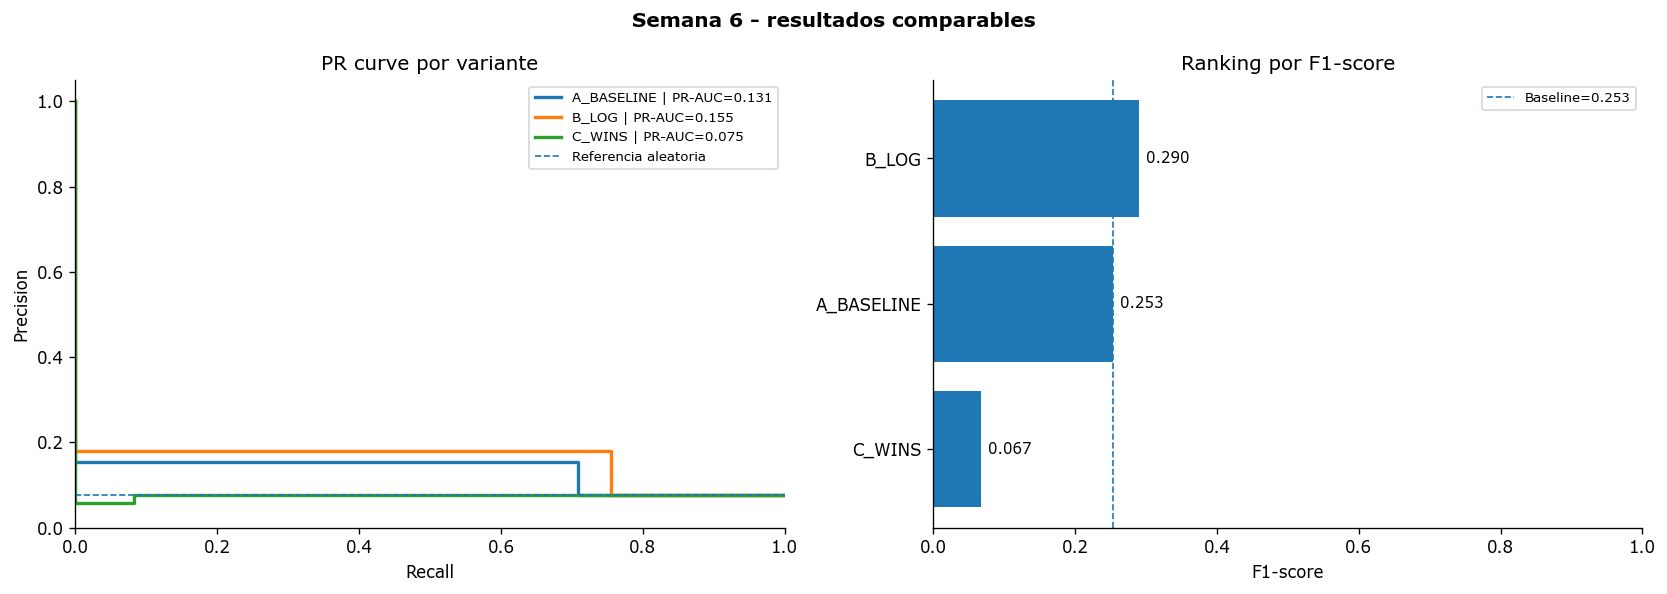

Figura guardada: outputs_semana6\figuras\semana6_pr_curve_ranking.png


In [8]:
# =============================================================================
# 6. GRAFICO UNICO DE RESULTADOS
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for variante, pred in predicciones.items():
    precision, recall, _ = precision_recall_curve(y_true, pred)
    pr_auc = average_precision_score(y_true, pred)
    axes[0].step(recall, precision, where="post", linewidth=2, label=f"{variante} | PR-AUC={pr_auc:.3f}")

axes[0].axhline(y_true.mean(), linestyle="--", linewidth=1, label="Referencia aleatoria")
axes[0].set_title("PR curve por variante")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=8)

ranking = tabla_resultados.sort_values("f1", ascending=True)
axes[1].barh(ranking["variante"], ranking["f1"])
for i, valor in enumerate(ranking["f1"]):
    axes[1].text(valor + 0.01, i, f"{valor:.3f}", va="center", fontsize=9)
axes[1].axvline(baseline_f1, linestyle="--", linewidth=1, label=f"Baseline={baseline_f1:.3f}")
axes[1].set_title("Ranking por F1-score")
axes[1].set_xlabel("F1-score")
axes[1].set_xlim(0, max(1.0, ranking["f1"].max() + 0.15))
axes[1].legend(fontsize=8)

plt.suptitle("Semana 6 - resultados comparables", fontweight="bold")
plt.tight_layout()
FIG_PATH = FIG_DIR / "semana6_pr_curve_ranking.png"
plt.savefig(FIG_PATH, dpi=120, bbox_inches="tight")
plt.show()

print(f"Figura guardada: {FIG_PATH}")

In [10]:
# =============================================================================
# 7. CONCLUSION, DECISION Y REPRODUCIBILIDAD
# =============================================================================

mejor = tabla_resultados.iloc[0]

tabla_export = tabla_resultados_round.copy()
tabla_export.insert(0, "fecha_ejecucion", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
tabla_export.insert(1, "seed", SEED)
tabla_export.insert(2, "split", TIPO_SPLIT)
tabla_export.insert(3, "periodo", f"{FEC_INI} a {FEC_FIN}")
tabla_export.insert(4, "hash_snapshot_sha256", HASH_SNAPSHOT)
tabla_export.to_csv(LOG_CSV, index=False, sep="|", encoding="utf-8")

readme = f"""
ENTREGA SPRINT SEMANA 6 - REPRODUCIBILIDAD

Comando sugerido:
    jupyter notebook sprint_semana6_resumido_autonomo.ipynb

Parametros:
    seed={SEED}
    periodo={FEC_INI} a {FEC_FIN}
    split={TIPO_SPLIT}
    metrica_principal=F1-score
    metricas_secundarias=precision, recall, PR-AUC, detectados, tasa_detectada, latencia_ms

Archivos generados:
    metricas={LOG_CSV}
    snapshot={SNAPSHOT_PATH}
    figura={FIG_PATH}

Hash snapshot SHA256:
    {HASH_SNAPSHOT}

Decision tecnica:
    adoptar={mejor['variante']} - {mejor['modelo']}
    f1={mejor['f1']:.4f}
    precision={mejor['precision']:.4f}
    recall={mejor['recall']:.4f}
    pr_auc={mejor['pr_auc']:.4f}
    latencia_ms={mejor['latencia_ms']:.4f}

Riesgos y siguientes pasos:
    1. La etiqueta y_true es proxy estadistica; requiere validacion experta para reducir falsos positivos.
    2. Monitorear drift por subpartida y aduana antes de pasar a un flujo productivo.
    3. Siguiente sprint: calibrar umbrales por familia de producto y revisar errores por variable.
""".strip()
README_PATH.write_text(readme, encoding="utf-8")

print("CONCLUSION Y DECISION")
print("=" * 80)
print(f"Variante adoptada : {mejor['variante']} - {mejor['modelo']}")
print(f"F1                : {mejor['f1']:.4f}")
print(f"Precision         : {mejor['precision']:.4f}")
print(f"Recall            : {mejor['recall']:.4f}")
print(f"PR-AUC            : {mejor['pr_auc']:.4f}")
print(f"Latencia ms       : {mejor['latencia_ms']:.4f}")
print()
print("Reproducibilidad")
print(f"Metricas : {LOG_CSV}")
print(f"Snapshot : {SNAPSHOT_PATH}")
print(f"README   : {README_PATH}")
print(f"Hash     : {HASH_SNAPSHOT}")

CONCLUSION Y DECISION
Variante adoptada : B_LOG - IQR sobre log1p(VU)
F1                : 0.2904
Precision         : 0.1798
Recall            : 0.7550
PR-AUC            : 0.1545
Latencia ms       : 79.7614

Reproducibilidad
Metricas : outputs_semana6\logs\metrics_experimentos_semana6.csv
Snapshot : outputs_semana6\datos\snapshot_semana6.csv
README   : outputs_semana6\README_REPRODUCIBILIDAD.txt
Hash     : bd70c05d1c0f5e10f3628e56fa6f31bf6042f3b7f774966ed8814b776517c97f
